In [2]:
import numpy as np
from numpy import linalg 

# modify from Chapter 4: 
# define a function for the central-difference derivative.
# x is now a NumPy array
# i is the component of the function (f_i) to be differentiated
# j is the component of the vector x to differentiate by (x_j)
def dfdt_CD_ND(funcvector, i, j, x, h): 
    """Calculates the central-difference partial derivative of a function func at vector x, in the j-th direction, with step size dx"""
    N = len(x) # get the length of the input array
    # increment only the j-th element by an amount dx
    dx = np.zeros(N) 
    dx[j] = h 
    return (funcvector(x+dx/2)[i] - funcvector(x-dx/2)[i])/h

# A higher-order function that calculates the Jacobian matrix for the N-dimensional vector of functions f_i:
# we will use a central-difference approximation to the derivatives, and a parameter h = 1E-5 for all directions 
def Jacobian(funcvector, x, h): # the input should be a NumPy array of functions, each of which is a function of N variables (x_i)
    """Calculate the Jacobian of the function vector as an NxN matrix using the central-difference approximation to the derivatives"""
    N = len(funcvector(x)) # get the number of dimensions
    output = np.zeros((N,N)) #  the output is an NxN NumPy array
    for i in range(N): # loop over the functions f_i
        for j in range(N): # loop over variables x_j:
            dfi_dxj = dfdt_CD_ND(funcvector, i,j,x,h)
            output[i][j] = dfi_dxj[0] # set this to the correct element of the Jacobian   
    return output 

# The N-D Newton-Raphson algorithm: 
# x0 is the initial guess, it should have the same dimensions as the number of variables! 
# Nmax is the number of evaluations
# prec is the required precision
# dx is the distance over which to take the central-difference derivative (not the same as the step size!)
def NewtonRaphsonND(func, x0, Nmax, prec, h): 
    """Function that implements the N-Dimensional Newton-Raphson algorithm for root finding"""
    # perform check that the number of dimensions is the same for the function and variables
    N = len(func(x0)) # get the number of dimensions
    if N != len(x0):
         raise Exception("The length of the function vector is not the same as the number of unknowns")
    n = 0 # the number of steps taken
    val = 1E99*np.ones(N) # the value of the equations, initialize to a large number
    roots = np.nan*np.ones(N) # initialize the roots to "not a number"
    for nn in range(Nmax): # loop runs up to the max number of evals, or up to the point where the precision is reached
        # get the values of the function at x0:
        minus_f = -func(x0)
        # check whether the required precision has been reached for *each* value:
        if np.all(np.abs(minus_f) < prec):
            n = nn # save the number of steps taken 
            print('Newton-Raphson Precision reached! Exiting')
            break # exit the loop nn
        # Get the Jacobian (J):
        J = Jacobian(func, x0, h)
        # calculate the step vector Dx using linear algebra (see Chapter 6, "NumPy's linalg Package" section)
        Dx = linalg.solve(J, minus_f).reshape(N) # turn this into the right shape (column vector)
        # update the guess and the value of the equation:
        x0 = np.add(x0, Dx)
    roots = x0
    return roots, n

In [16]:
# data points:

xdata = [0, 25, 50, 75, 100, 125, 150, 175, 200]
ydata = [10.6, 16.0, 45.0, 83.5, 52.8, 19.9, 10.8, 8.25, 4.7]

# define fitting function:
def g(x, a):
    return a[0] / ((x-a[1])**2 + a[2])
    
# define function:
# CHECK Jacobian with non-linear functions:
def function_for_fit(a):
    f1 = 0
    f2 = 0
    f3 = 0
    for i in range(len(xdata)): # sum over the data (i=1 to i=9)
        f1 += (ydata[i] - g(xdata[i], a))/((xdata[i]-a[1])**2 + a[2])
        f2 += (ydata[i] - g(xdata[i], a)) * (xdata[i]-a[1])/((xdata[i]-a[1])**2 + a[2])**2
        f3 += (ydata[i] - g(xdata[i], a))/((xdata[i]-a[1])**2 + a[2])**2
    funcmatrix = np.array([[f1], [f2], [f3]])
    return funcmatrix

# initial guess
x0 = [80000, 75, 500]
Nmax = 100000
prec = 1E-5
h = 1E-5
# (c) CHECK the non-linear function:
roots, niterations = NewtonRaphsonND(function_for_fit, x0, Nmax, prec, h)
print('The roots of the non-linear equations are=', roots)


Newton-Raphson Precision reached! Exiting
The roots of the non-linear equations are= [66886.11849822    77.49369651   788.8781973 ]


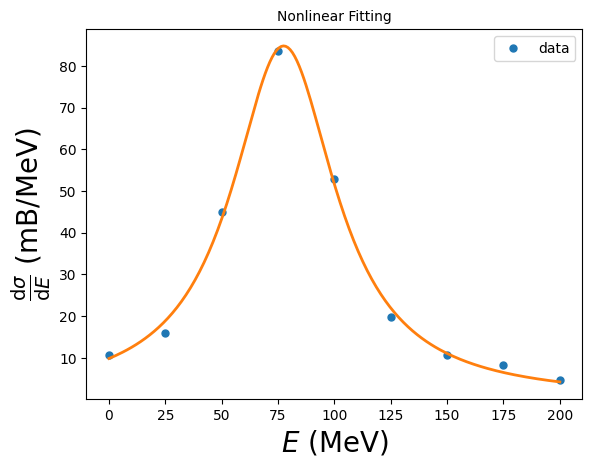

In [4]:
# and now let's plot: 
import matplotlib.pyplot as plt # import matplotlib, a conventional module name is plt
import numpy as np

fig, ax = plt.subplots() # create the elements required for matplotlib. This creates a figure containing a single axes.

# set the labels and titles:
ax.set_xlabel(r'$E$ (MeV)', fontsize=20) # set the x label
ax.set_ylabel(r'$\frac{\mathrm{d}\sigma}{\mathrm{d}E}$ (mB/MeV)', fontsize=20) # set the y label 
ax.set_title('Nonlinear Fitting', fontsize=10) # set the title 

# plot the data
ax.plot(xdata, ydata, label='data', lw=0,ms=5,marker='o') 
# plot the fit
xforplot = np.linspace(0,200,200)
ax.plot(xforplot, g(xforplot,roots),ls='-', marker='', lw=2)

# construct the legend:
ax.legend(loc='upper right')  # Add a legend

plt.show() # show the plot here

